In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib import ticker
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from scipy import stats
import matplotlib.ticker as mticker
import colormaps as cmaps
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.colorbar as colorbar
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

In [2]:
GPP_baseline = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_01_29_baseline_run/baseline_withfire/output/mgpp.nc").GPP.sel(time = slice('2000-03','2019'))
# Convert CFTimeIndex to pandas datetime
time_as_timestamp = pd.to_datetime(GPP_baseline["time"].values.astype(str))

# Convert to period
time_as_period = time_as_timestamp.to_period("M")
time_as_timestamp = time_as_period.to_timestamp(how="start")

# Update the time coordinate in the DataArray
GPP_baseline = GPP_baseline.assign_coords(time=time_as_timestamp)
GPP_baseline

<xarray.DataArray 'GPP' (time: 238, lat: 1397, lon: 3600)> Size: 5GB
[1196949600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[us] 2kB 2000-03-01 2000-04-01 ... 2019-12-01
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:          gC/m2/month
    standard_name:  GPP
    long_name:      GPP

In [3]:
GPP_monthlymort = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_01_29_baseline_run/monthlybackground_withfire/output/mgpp.nc").GPP.sel(time = slice('2000-03','2019'))
# Convert CFTimeIndex to pandas datetime
time_as_timestamp = pd.to_datetime(GPP_monthlymort["time"].values.astype(str))

# Convert to period
time_as_period = time_as_timestamp.to_period("M")
time_as_timestamp = time_as_period.to_timestamp(how="start")

# Update the time coordinate in the DataArray
GPP_monthlymort = GPP_monthlymort.assign_coords(time=time_as_timestamp)
GPP_monthlymort

<xarray.DataArray 'GPP' (time: 238, lat: 1397, lon: 3600)> Size: 5GB
[1196949600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[us] 2kB 2000-03-01 2000-04-01 ... 2019-12-01
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:          gC/m2/month
    standard_name:  GPP
    long_name:      GPP

In [5]:
GPP_droughtmort = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_03_27_global_droughtmort/output_withfire/output/mgpp.nc").GPP.sel(time = slice('2000-03','2019'))
# Convert CFTimeIndex to pandas datetime
time_as_timestamp = pd.to_datetime(GPP_droughtmort["time"].values.astype(str))

# Convert to period
time_as_period = time_as_timestamp.to_period("M")
time_as_timestamp = time_as_period.to_timestamp(how="start")

# Update the time coordinate in the DataArray
GPP_droughtmort = GPP_droughtmort.assign_coords(time=time_as_timestamp)
GPP_droughtmort

<xarray.DataArray 'GPP' (time: 238, lat: 1397, lon: 3600)> Size: 5GB
[1196949600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[us] 2kB 2000-03-01 2000-04-01 ... 2019-12-01
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:          gC/m2/month
    standard_name:  GPP
    long_name:      GPP

In [6]:
GPP_MODIS = xr.open_dataset("/projects/prjs2023/chapter3/MODIS/GPP_MODIS_landseamask_01deg.nc").Gpp.sel(time = slice('2000-03','2019'))
# Convert CFTimeIndex to pandas datetime
time_as_timestamp = pd.to_datetime(GPP_MODIS["time"].values.astype(str))

# Convert to period
time_as_period = time_as_timestamp.to_period("M")
time_as_timestamp = time_as_period.to_timestamp(how="start")

# Update the time coordinate in the DataArray
GPP_MODIS = GPP_MODIS.assign_coords(time=time_as_timestamp)
GPP_MODIS

<xarray.DataArray 'Gpp' (time: 238, lat: 1397, lon: 3600)> Size: 10GB
[1196949600 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[us] 2kB 2000-03-01 2000-04-01 ... 2019-12-01
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0

In [7]:
GPP_baseline['lon'] = GPP_monthlymort.lon
GPP_baseline['lat'] = GPP_monthlymort.lat
GPP_MODIS['lon'] = GPP_monthlymort.lon
GPP_MODIS['lat'] = GPP_monthlymort.lat
GPP_droughtmort['lon'] = GPP_monthlymort.lon
GPP_droughtmort['lat'] = GPP_monthlymort.lat

In [8]:
lc = xr.open_dataset("/projects/prjs2023/chapter3/landcover/C3S-LC-L4-LCCS-Map-01deg_remapnn-P1Y-2022-v2.1.1.nc").lccs_class[0].sel(lat = slice(-56.0,83.7))
lc['lat'] = GPP_monthlymort.lat
lc['lon'] = GPP_monthlymort.lon
valid_mask = (lc != 220) & (lc != 210) & (lc != 200) & (lc != 150)

In [9]:

# Define your region configs
region_configs = [
    {
        "region_name": "CAL",
        "spei_path": "/projects/prjs2023/chapter3/SPEI/focus_regions/SPEI12_monthly_1950_2019_0_5_degree_CAL.nc",
        "mask_path": "/projects/prjs2023/chapter3/remapped_masks/mask_CAL_0_1_degrees.nc",
        "reg_lat": slice(30, 43),
        "reg_lon": slice(-126, -113),
        "zoom_start": "2000-01-01",
        "zoom_end": "2019-12-31"
    },
    {
        "region_name": "WEU",
        "spei_path": "/projects/prjs2023/chapter3/SPEI/focus_regions/SPEI12_monthly_1950_2019_0_5_degree_WEU.nc",
        "mask_path": "/projects/prjs2023/chapter3/remapped_masks/mask_WEU_0_1_degrees.nc",
        "reg_lat": slice(41, 57),
        "reg_lon": slice(-2, 14),
        "zoom_start": "2000-01-01",
        "zoom_end": "2019-12-31"
    },
    {
        "region_name": "BRA",
        "spei_path": "/projects/prjs2023/chapter3/SPEI/focus_regions/SPEI12_monthly_1950_2019_0_5_degree_BAH.nc",
        "mask_path": "/projects/prjs2023/chapter3/remapped_masks/mask_Brahmaputra_0_1_degrees.nc",
        "reg_lat": slice(19, 37),
        "reg_lon": slice(81, 99),
        "zoom_start": "2000-01-01",
        "zoom_end": "2019-12-31"
    },
    {
        "region_name": "ARG",
        "spei_path": "/projects/prjs2023/chapter3/SPEI/focus_regions/SPEI12_monthly_1950_2019_0_5_degree_ARG.nc",
        "mask_path": "/projects/prjs2023/chapter3/remapped_masks/mask_ARG_0_1_degrees.nc",
        "reg_lat": slice(-56, -26),
        "reg_lon": slice(-80, -50),
        "zoom_start": "2000-01-01",
        "zoom_end": "2019-12-31"
    },
    {
        "region_name": "SA",
        "spei_path": "/projects/prjs2023/chapter3/SPEI/focus_regions/SPEI12_monthly_1950_2019_0_5_degree_SA.nc",
        "mask_path": "/projects/prjs2023/chapter3/remapped_masks/mask_SA_0_1_degrees.nc",
        "reg_lat": slice(-37, -15),
        "reg_lon": slice(13, 35),
        "zoom_start": "2000-01-01",
        "zoom_end": "2019-12-31"
    },
    {
        "region_name": "AUS",
        "spei_path": "/projects/prjs2023/chapter3/SPEI/focus_regions/SPEI12_monthly_1950_2019_0_5_degree_AUS.nc",
        "mask_path": "/projects/prjs2023/chapter3/remapped_masks/mask_AUS_0_1_degrees.nc",
        "reg_lat": slice(-39.9, -19.9),
        "reg_lon": slice(135, 155),
        "zoom_start": "2000-01-01",
        "zoom_end": "2019-12-31"
    }
]

In [10]:
def compute_means_fast(region_configs, GPP_baseline, GPP_monthlymort, GPP_droughtmort, gpp_modis):
    results = []

    # Optional but highly recommended: chunk data
    GPP_baseline = GPP_baseline.chunk({"time": 50})
    GPP_monthlymort = GPP_monthlymort.chunk({"time": 50})
    GPP_droughtmort = GPP_droughtmort.chunk({"time": 50})
    gpp_modis = gpp_modis.chunk({"time": 50})

    for config in region_configs:
        region_name = config["region_name"]
        print(f"Processing region: {region_name}")
        
        # --- Load SPEI ONCE per region (OK, different files) ---
        SPEI = xr.open_dataset(config["spei_path"], chunks={"time": 50}).__xarray_dataarray_variable__

        # --- Load mask ---
        mask = xr.open_dataarray(config["mask_path"]).sel(
            lat=config["reg_lat"], 
            lon=config["reg_lon"]
        )

        # --- Subset data ---
        baseline = GPP_baseline.sel(lat=config["reg_lat"], lon=config["reg_lon"])
        monthly = GPP_monthlymort.sel(lat=config["reg_lat"], lon=config["reg_lon"])
        drought = GPP_droughtmort.sel(lat=config["reg_lat"], lon=config["reg_lon"])
        modis = gpp_modis.sel(lat=config["reg_lat"], lon=config["reg_lon"])

        # --- Apply mask + mean (lazy) ---
        baseline_mean = baseline.where(mask == 1).mean(['lat', 'lon'])
        monthly_mean = monthly.where(mask == 1).mean(['lat', 'lon'])
        drought_mean = drought.where(mask == 1).mean(['lat', 'lon'])
        modis_mean = modis.where(mask == 1).mean(['lat', 'lon'])

        # --- Subset SPEI to region + mean ---
        SPEI_region = SPEI
        SPEI_mean = SPEI_region

        results.append({
            "region_name": region_name,
            "gpp_baseline_mean": baseline_mean,
            "gpp_monthlymort_mean": monthly_mean,
            "gpp_droughtmort_mean": drought_mean,
            "gpp_modis_mean": modis_mean,
            "SPEI_mean": SPEI_mean,
            "zoom_start": config["zoom_start"],
            "zoom_end": config["zoom_end"]
        })

    # Trigger computation only once at the end
    results = [{
        **r,
        "gpp_baseline_mean": r["gpp_baseline_mean"].compute(),
        "gpp_monthlymort_mean": r["gpp_monthlymort_mean"].compute(),
        "gpp_droughtmort_mean": r["gpp_droughtmort_mean"].compute(),
        "gpp_modis_mean": r["gpp_modis_mean"].compute(),
        "SPEI_mean": r["SPEI_mean"].compute(),
    } for r in results]

    return results

In [11]:
# def compute_means(region_configs, GPP_baseline, GPP_monthlymort, GPP_droughtmort, gpp_modis):
#     results = []

#     for config in region_configs:
#         region_name = config["region_name"]
#         print(f"Processing region: {region_name}")
        
#         # Load region-specific data
#         spei_ds = xr.open_dataset(config["spei_path"])
#         SPEI = spei_ds.__xarray_dataarray_variable__
        
#         mask = xr.open_dataarray(config["mask_path"]).sel(
#             lat=config["reg_lat"], 
#             lon=config["reg_lon"]
#         )
        
#         # Subset all datasets
#         baseline = GPP_baseline.sel(lat=config["reg_lat"], lon=config["reg_lon"])
#         monthly = GPP_monthlymort.sel(lat=config["reg_lat"], lon=config["reg_lon"])
#         drought = GPP_droughtmort.sel(lat=config["reg_lat"], lon=config["reg_lon"])
#         modis = gpp_modis.sel(lat=config["reg_lat"], lon=config["reg_lon"])

#         # Apply mask and compute spatial means
#         baseline_mean = baseline.where(mask == 1).mean(['lat', 'lon'])
#         monthly_mean = monthly.where(mask == 1).mean(['lat', 'lon'])
#         drought_mean = drought.where(mask == 1).mean(['lat', 'lon'])
#         modis_mean = modis.where(mask == 1).mean(['lat', 'lon'])

#         # SPEI (keep as-is or spatial mean if needed)
#         SPEI_mean = SPEI  # or SPEI.where(mask == 1).mean(['lat','lon'])

#         results.append({
#             "region_name": region_name,
#             "gpp_baseline_mean": baseline_mean,
#             "gpp_monthlymort_mean": monthly_mean,
#             "gpp_droughtmort_mean": drought_mean,
#             "gpp_modis_mean": modis_mean,
#             "SPEI_mean": SPEI_mean,
#             "zoom_start": config["zoom_start"],
#             "zoom_end": config["zoom_end"]
#         })

#     return results

In [12]:
results = compute_means_fast(region_configs, GPP_baseline, GPP_monthlymort, GPP_droughtmort, GPP_MODIS)
results

Processing region: CAL
Processing region: WEU
Processing region: BRA
Processing region: ARG
Processing region: SA
Processing region: AUS


[{'region_name': 'CAL',
  'gpp_baseline_mean': <xarray.DataArray 'GPP' (time: 238)> Size: 952B
  array([126.591644, 112.4873  ,  74.88542 ,  34.27114 ,  22.663877,
          19.041529,  29.653551,  45.95269 ,  56.91165 ,  47.316017,
          54.592052,  73.7766  , 130.15237 , 109.98093 ,  66.38355 ,
          28.348423,  24.943222,  18.319176,  19.247595,  25.277088,
          52.403336,  42.69181 ,  54.45799 ,  80.760704, 100.16841 ,
          81.38369 ,  68.628204,  30.423477,  19.151136,  16.42107 ,
          18.287853,  21.494774,  57.408035,  48.8847  ,  82.712654,
          80.485275, 125.7775  , 113.98266 ,  94.98043 ,  38.073536,
          27.261446,  30.658842,  28.29236 ,  27.490942,  51.30613 ,
          41.643505,  62.095272,  76.21499 , 134.07448 ,  90.78677 ,
          50.43315 ,  22.208855,  17.070713,  17.05694 ,  17.537123,
          44.228577,  76.39859 ,  52.59003 ,  64.061554,  89.09178 ,
         133.76    , 127.170425, 100.77788 ,  42.837193,  30.234222,
        

CAL correlations:
  Baseline vs MODIS: 0.39
  MonthlyMort vs MODIS: 0.39
  DroughtMort vs MODIS: 0.39
WEU correlations:
  Baseline vs MODIS: 0.83
  MonthlyMort vs MODIS: 0.83
  DroughtMort vs MODIS: 0.83
BRA correlations:
  Baseline vs MODIS: 0.38
  MonthlyMort vs MODIS: 0.38
  DroughtMort vs MODIS: 0.38
ARG correlations:
  Baseline vs MODIS: 0.87
  MonthlyMort vs MODIS: 0.87
  DroughtMort vs MODIS: 0.87
SA correlations:
  Baseline vs MODIS: 0.84
  MonthlyMort vs MODIS: 0.84
  DroughtMort vs MODIS: 0.84
AUS correlations:
  Baseline vs MODIS: 0.73
  MonthlyMort vs MODIS: 0.73
  DroughtMort vs MODIS: 0.74


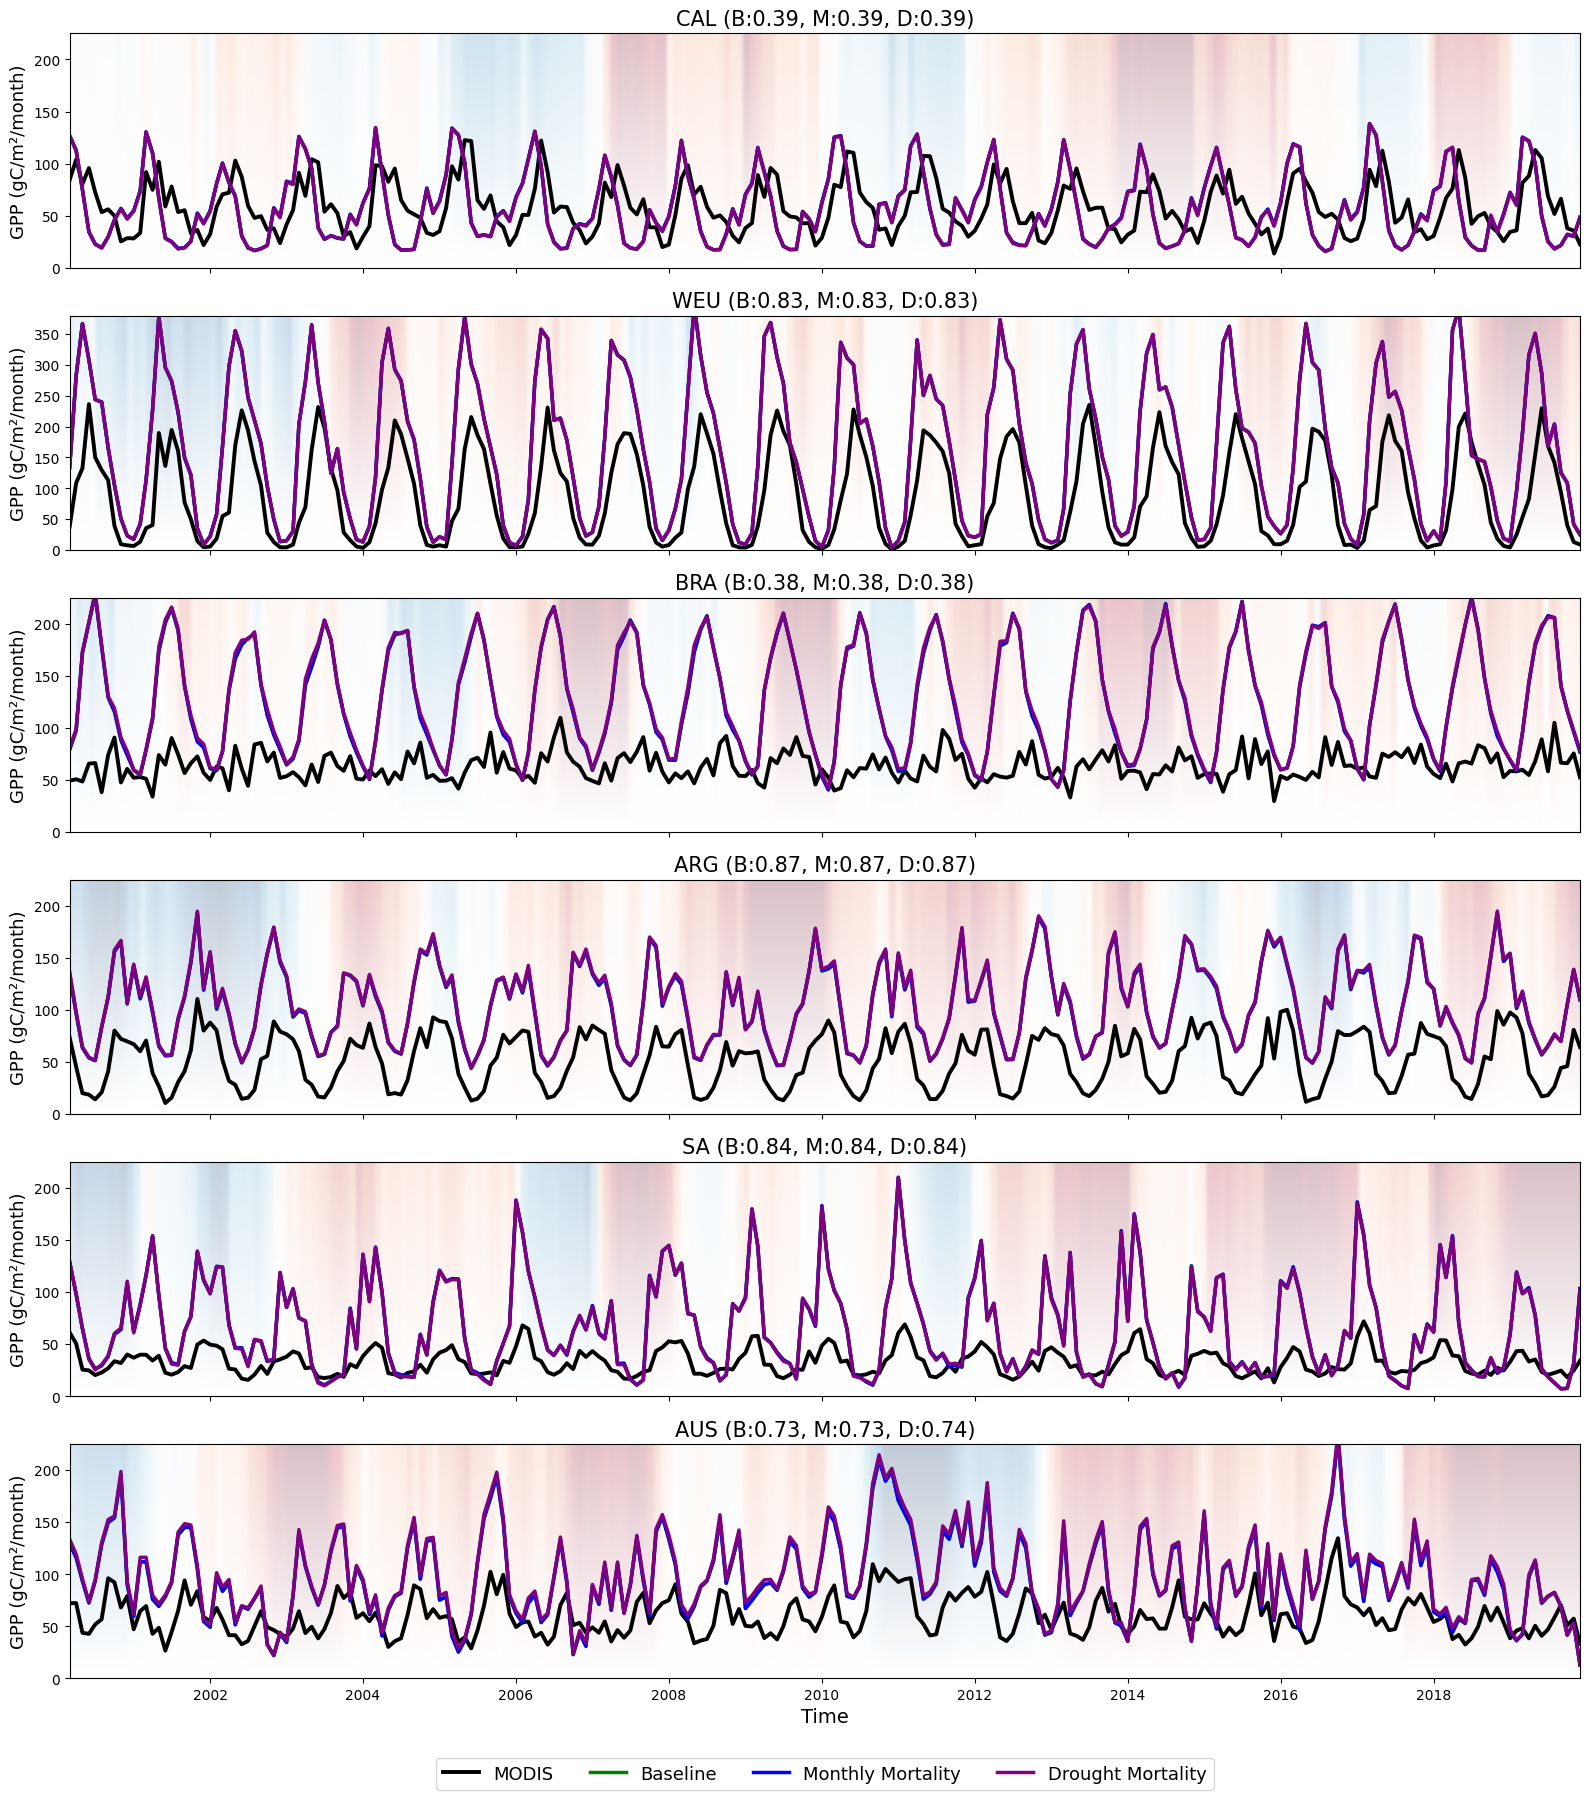

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
from matplotlib.colors import Normalize

def plot_all_regions(precomputed_results):
    fig, axes = plt.subplots(len(precomputed_results), 1, figsize=(16, 18), sharex=True)

    for i, region in enumerate(precomputed_results):
        ax = axes[i]
        region_name = region["region_name"]
        zoom_start = region["zoom_start"]
        zoom_end = region["zoom_end"]

        # --- GPP datasets ---
        baseline = region["gpp_baseline_mean"].sel(time=slice(zoom_start, zoom_end)).to_pandas()
        monthly = region["gpp_monthlymort_mean"].sel(time=slice(zoom_start, zoom_end)).to_pandas()
        drought = region["gpp_droughtmort_mean"].sel(time=slice(zoom_start, zoom_end)).to_pandas()
        modis = region["gpp_modis_mean"].sel(time=slice(zoom_start, zoom_end)).to_pandas()

        # Fix MODIS time index
        modis.index = pd.to_datetime([pd.Timestamp(str(t)) for t in modis.index]).to_period('M').to_timestamp()

        # --- SPEI ---
        spei_zoom = region["SPEI_mean"].sel(time=slice(zoom_start, zoom_end))

        # --- Correlations (example: baseline vs MODIS) ---
        corr_baseline = baseline.corr(modis)
        corr_monthly = monthly.corr(modis)
        corr_drought = drought.corr(modis)

        print(f"{region_name} correlations:")
        print(f"  Baseline vs MODIS: {corr_baseline:.2f}")
        print(f"  MonthlyMort vs MODIS: {corr_monthly:.2f}")
        print(f"  DroughtMort vs MODIS: {corr_drought:.2f}")

        # --- SPEI background ---
        times = spei_zoom.time.values
        norm = Normalize(vmin=-2, vmax=2)
        cmap = cm.RdBu

        rgba_row = cmap(norm(spei_zoom.values))
        rgba_image = np.tile(rgba_row, (100, 1, 1))

        alpha_mask = np.linspace(0.25, 0.0, rgba_image.shape[0]).reshape(-1, 1)
        rgba_image[:, :, 3] *= alpha_mask

        ax.imshow(
            rgba_image,
            extent=[times[0], times[-1], 0, 1],
            aspect='auto',
            zorder=0,
            transform=ax.get_xaxis_transform()
        )

        # --- Plot lines ---
        ax.plot(modis.index, modis, color="black", linewidth=2.8, label="MODIS")
        ax.plot(baseline.index, baseline, color="green", linewidth=2.5, label="Baseline")
        ax.plot(monthly.index, monthly, color="blue", linewidth=2.5, label="Monthly Mortality")
        ax.plot(drought.index, drought, color="purple", linewidth=2.5, label="Drought Mortality")

        # --- Formatting ---
        ax.set_xlim([modis.index[0], modis.index[-1]])
        if region_name == "WEU":
            ax.set_ylim([0, 380])
        else:
            ax.set_ylim([0, 225])

        ax.set_ylabel("GPP (gC/m²/month)", fontsize=13)
        ax.set_title(
            f"{region_name} "
            f"(B:{corr_baseline:.2f}, M:{corr_monthly:.2f}, D:{corr_drought:.2f})",
            fontsize=15
        )
        ax.tick_params(labelsize=10)

    axes[-1].legend(loc="upper center", ncol=4, fontsize=13, bbox_to_anchor=(0.5, -0.3))
    plt.xlabel("Time", fontsize=14)

    plt.tight_layout()
    plt.savefig(
        "/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_03_27_global_droughtmort/GPP_timeseries_withfire.png",
        bbox_inches="tight",
        dpi=1200
    )
    plt.show()

plot_all_regions(results)

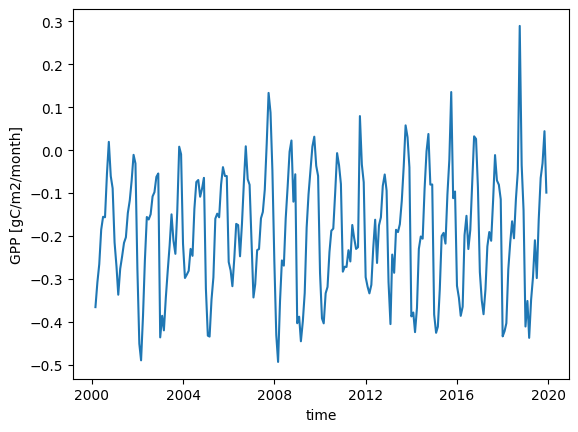

In [23]:
(results[0]['gpp_baseline_mean'] - results[0]['gpp_monthlymort_mean']).plot()